In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import numpy as np
# from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
import seaborn as sns
# from joblib import Parallel, delayed
import re
import os
from itertools import combinations
# from statsmodels.stats.multitest import multipletests


The purpose of this notebook is to create

- Figure 2a: a bar plot comparing the performance (precision and recall) of the models on the cogntive status tasks (NC/MCI/DE), with stats using bootstrap.
- A table containing the same data, plus the F1 score. The table is in LaTeX format, ready to be pasted into the manuscript.

Notice that we are only loading the COG task

In [2]:
# Define mappings
model_map = {
    "Qwen2.5-3B-Instruct": "Q3B",
    "NACC-3B": "LUNAR-OS-SCe",
    "NACC-3B-SCE": "LUNAR-OS",
    "NACC-3B-OS": "LUNAR-SCe",
    "NACC-3B-OS-SCE": "LUNAR",
    "Qwen2.5-7B-Instruct": "Q7B",
}

class_map = {
    'Mild Cognitive Impairment (MCI)': 'MCI',
    'Dementia (DE)': 'DE',
    'Normal Cognition (NC)': 'NC'
}

# Load the data

In [3]:
nifd_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/NIFD/test_cog')
nacc_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/NACC/test_cog')
adni_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/ADNI/test_cog')
ppmi_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/PPMI/test_cog')
brainlat_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/brainlat/test_cog')

The following functions load the data from the paths specified above, pick only relevant columns, and concatenate everything. 

Later we compute class-wise precision and recall, and estimate error bars on them using bootstrap. The bootstrap samples are kept, so we can compute anything else we want after resampling, ensuring that the calculations use the correct samples.

In [4]:
def option_string_to_dict(options):
    # The option string is randomized (e.g. NC is not always option A). We need to break down the 
    # options and look at the text (e.g. MCI), not just the letter that identifies them in a particular question
    pattern = r"([A-Z])\. ([^\n]+)"
    matches = re.findall(pattern, options)
    return {key: value for key, value in matches}

def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction. 
    # Reading only those columns is significantly faster (about 100x) than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings (model outputs) in some columns

    fpaths = list(dir_path.rglob('*.parquet'))

    dfs = []

    cols_to_read = ['ID','ground_truth','prediction','ground_truth_text','options']#, 'generated_text']

    for fpath in tqdm(fpaths):

        model = fpath.parent.name.split('-',3)[-1] 
        benchmark = fpath.parent.parent.name.split('_',1)[-1].upper()

        df = pd.read_parquet(fpath,columns=cols_to_read)
    
        df = df.assign(model=model, benchmark=benchmark)

        df['correct'] = (df['ground_truth'] == df['prediction']).astype(int)

        df['prediction_text'] = df.apply(lambda row: option_string_to_dict(row['options']).get(row['prediction'],'invalid'),axis=1)

        dfs.append(df)

    df = pd.concat(dfs)
    df['dataset'] = dataset_name

    # make these columns Categorical
    group_cols = ["dataset", "benchmark", "model", "ground_truth_text", 'prediction_text']
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    # keep only the models we actually care about
    df = df[df['model'].isin(list(model_map.keys()))]

    return df


The `dataset_name` parameter will be used in the results dataset to identify which dataset the data came from

In [5]:
nacc_res = load_answers(nacc_path,dataset_name='NACC')

100%|██████████| 8/8 [00:09<00:00,  1.25s/it]


In [6]:
nacc_res.prediction_text.unique()

['Normal Cognition (NC)', 'Mild Cognitive Impairment (MCI)', 'Dementia (DE)', 'invalid']
Categories (4, object): ['Dementia (DE)', 'Mild Cognitive Impairment (MCI)', 'Normal Cognition (NC)', 'invalid']

In [7]:
brainlat_res = load_answers(brainlat_path,dataset_name='BrainLat')

100%|██████████| 8/8 [00:00<00:00, 12.09it/s]


In [8]:
ppmi_res = load_answers(ppmi_path,dataset_name='PPMI')

100%|██████████| 8/8 [00:01<00:00,  4.56it/s]


In [9]:
nifd_res = load_answers(nifd_path,dataset_name='NIFD')

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 14.13it/s]


In [10]:
adni_res = load_answers(adni_path,dataset_name='ADNI')

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  6.57it/s]


In [11]:
# concatenate everything in a tall format dataframe

results_df = pd.concat(
    [
        nacc_res,
        adni_res,
        brainlat_res,
        nifd_res,
        ppmi_res
    ]
).reset_index(drop=True)

In [12]:
results_df['dataset_raw'] = results_df['dataset']

results_df['dataset'] = results_df['dataset'].replace(
    {
        'ADNI':'Other',
        'BrainLat':'Other',
        'NIFD':'Other',
        'PPMI':'Other',
    }
)
results_df["trial"] = results_df.index

In [13]:
results_df.head()

,ID,ground_truth,prediction,ground_truth_text,options,model,benchmark,correct,prediction_text,dataset,dataset_raw,trial
0,NACC513030,C,B,Mild Cognitive Impairment (MCI),A. Dementia (DE)\nB. Normal Cognition (NC)\nC....,Qwen2.5-3B-Instruct,COG,0,Normal Cognition (NC),NACC,NACC,0
1,NACC513030,C,C,Mild Cognitive Impairment (MCI),A. Dementia (DE)\nB. Normal Cognition (NC)\nC....,Qwen2.5-3B-Instruct,COG,1,Mild Cognitive Impairment (MCI),NACC,NACC,1
2,NACC513030,C,C,Mild Cognitive Impairment (MCI),A. Dementia (DE)\nB. Normal Cognition (NC)\nC....,Qwen2.5-3B-Instruct,COG,1,Mild Cognitive Impairment (MCI),NACC,NACC,2
3,NACC513030,C,C,Mild Cognitive Impairment (MCI),A. Dementia (DE)\nB. Normal Cognition (NC)\nC....,Qwen2.5-3B-Instruct,COG,1,Mild Cognitive Impairment (MCI),NACC,NACC,3
4,NACC513030,C,C,Mild Cognitive Impairment (MCI),A. Dementia (DE)\nB. Normal Cognition (NC)\nC....,Qwen2.5-3B-Instruct,COG,1,Mild Cognitive Impairment (MCI),NACC,NACC,4


In [14]:
results_df['model'].unique()

['Qwen2.5-3B-Instruct', 'NACC-3B-OS', 'NACC-3B-SCE', 'NACC-3B', 'NACC-3B-OS-SCE', 'Qwen2.5-7B-Instruct']
Categories (8, object): ['NACC-3B', 'NACC-3B-OS', 'NACC-3B-OS-SCE', 'NACC-3B-SCE', 'NACC-7B-OS', 'NACC-7B-OS-SCE', 'Qwen2.5-3B-Instruct', 'Qwen2.5-7B-Instruct']

# Metrics

In [15]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from itertools import combinations
from statsmodels.stats.multitest import multipletests

def _vectorized_metric_calc(y_true, y_pred, label_code, metric):
    """Core vectorized math for both bootstrap and permutation."""
    tp = np.sum((y_pred == label_code) & (y_true == label_code), axis=-1)
    
    if metric == 'precision':
        den = np.sum(y_pred == label_code, axis=-1)
    elif metric == 'recall':
        den = np.sum(y_true == label_code, axis=-1)
    elif metric == 'f1':
        precision_den = np.sum(y_pred == label_code, axis=-1)
        recall_den = np.sum(y_true == label_code, axis=-1)
        precision = np.divide(
            tp, precision_den, out=np.zeros_like(tp, dtype=float), where=precision_den != 0
        )
        recall = np.divide(
            tp, recall_den, out=np.zeros_like(tp, dtype=float), where=recall_den != 0
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            f1 = np.divide(
                2 * precision * recall,
                precision + recall,
                out=np.zeros_like(tp, dtype=float),
                where=(precision + recall) != 0,
            )
        return f1
    else:
        raise ValueError(f"Unknown metric: {metric}")
    return np.divide(tp, den, out=np.zeros_like(tp, dtype=float), where=den != 0)



# Bootstrap

In [26]:
def _single_bootstrap_task(group_info, y_true_b, y_pred_b, lbl_code, m_type):
    """Worker for individual bootstrap metric tasks to saturate 20+ cores."""
    boot_values = _vectorized_metric_calc(y_true_b, y_pred_b, lbl_code, m_type)
    low, med, high = np.percentile(boot_values, [2.5, 50, 97.5])
    return {
        **group_info, "class_code": lbl_code, "metric": m_type,
        "mean": np.mean(boot_values), "median": med, "low": low, "high": high
    }

def optimized_bootstrap_parallel(df, n_boot=1000, seed=42, n_jobs=-1):
    """
    Bootstrap CIs for precision/recall per (dataset, benchmark, model, class).
    """
    # Keep original text columns for grouping
    df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()
    
    # Build tasks
    groups = list(df_grouped.groupby(["dataset", "model"], observed=True))
    print(len(groups))
    main_rng = np.random.default_rng(seed)
    all_tasks = []
    
    # We'll build a global int_to_label mapping after collecting all groups
    all_int_to_label = {}
    
    print(f"Preparing Bootstrap data for {len(groups)} groups...")
    
    for i, (g_id, group) in enumerate(groups):
        # Sort by ID for consistency
        group = group.sort_values(['ID', "trial"]).reset_index(drop=True)
        
        # Get all unique categories for THIS group
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        # Ensure 'invalid' is included
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        # Create shared categorical dtype for this group
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        # Encode with consistent mapping
        y_true = group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        y_pred = group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        
        # Labels to process (exclude invalid)
        labels_to_process = [i for i in range(len(all_cats)) if i != invalid_code]
        
        # Store mapping for this group (we'll merge later)
        group_key = (g_id[0], g_id[1])
        all_int_to_label[group_key] = {i: cat for i, cat in enumerate(all_cats)}
        
        group_seed = int(main_rng.integers(0, 2**32))
        rng = np.random.default_rng(group_seed)
        
        # Generate indices once per group
        indices = rng.integers(0, len(y_true), size=(n_boot, len(y_true)))
        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        
        for lbl_code in labels_to_process:
            for m_type in ['precision', 'recall', 'f1']:
                all_tasks.append((
                    {"dataset": g_id[0], "model": g_id[1]},
                    y_true_b, y_pred_b, lbl_code, m_type
                ))
    
    print(f"Executing Bootstrap on {len(all_tasks)} tasks across {n_jobs} cores...")
    results = Parallel(n_jobs=n_jobs)(delayed(_single_bootstrap_task)(*t) for t in all_tasks)
    
    res_df = pd.DataFrame(results)
    
    # Map class codes back to labels using group-specific mappings
    res_df['class'] = res_df.apply(
        lambda row: all_int_to_label[(row['dataset'], row['model'])][row['class_code']],
        axis=1
    )
    
    return res_df.drop(columns=['class_code'])

In [27]:
# Step 1: Compute bootstrap CIs with samples
all_metrics = optimized_bootstrap_parallel(
    results_df, n_boot=100, seed=42, n_jobs=20
)

12
Preparing Bootstrap data for 12 groups...
Executing Bootstrap on 108 tasks across 20 cores...


In [23]:
all_metrics.sort_values(['dataset','model','metric','class'])[:20]

,dataset,benchmark,model,metric,mean,median,low,high,class
2,NACC,COG,NACC-3B,f1,0.863812,0.863874,0.861786,0.865833,Dementia (DE)
5,NACC,COG,NACC-3B,f1,0.508675,0.508489,0.504389,0.512788,Mild Cognitive Impairment (MCI)
8,NACC,COG,NACC-3B,f1,0.849084,0.849117,0.846909,0.850999,Normal Cognition (NC)
0,NACC,COG,NACC-3B,precision,0.937628,0.937609,0.935330,0.939973,Dementia (DE)
3,NACC,COG,NACC-3B,precision,0.389639,0.389569,0.385369,0.393601,Mild Cognitive Impairment (MCI)
6,NACC,COG,NACC-3B,precision,0.932891,0.932991,0.930932,0.934696,Normal Cognition (NC)
1,NACC,COG,NACC-3B,recall,0.800772,0.800761,0.798138,0.803629,Dementia (DE)
4,NACC,COG,NACC-3B,recall,0.732454,0.732712,0.727359,0.737475,Mild Cognitive Impairment (MCI)
7,NACC,COG,NACC-3B,recall,0.779095,0.779147,0.776599,0.782319,Normal Cognition (NC)
11,NACC,COG,NACC-3B-OS,f1,0.890892,0.890892,0.889386,0.892700,Dementia (DE)


# Permutation testing

In [19]:
def _permutation_worker(task, n_perms, seed):
    """Worker for individual permutation tasks."""
    rng = np.random.default_rng(seed)
    id_array = task["id_array"]
    yt, yp1, yp2, lbl_code, m_type = task['yt'], task['yp1'], task['yp2'], task['class_code'], task['metric']
    
    obs_diff = _vectorized_metric_calc(yt, yp1, lbl_code, m_type) - _vectorized_metric_calc(yt, yp2, lbl_code, m_type)
    
    # Vectorized swap across all permutations
    unique_ids, id_indices = np.unique(id_array, return_inverse=True)
    n_ids = len(unique_ids)
    
    # Generate ALL permutations at once: shape (n_perms, n_ids)
    swap_ids = rng.integers(0, 2, size=(n_perms, n_ids), dtype=bool)
    
    # Map ID-level swaps to trial-level: shape (n_perms, n_samples)
    swap = swap_ids[:, id_indices] 
    
    # Now we can vectorize again
    p1 = np.where(swap[:, None], yp2, yp1)  # Shape: (n_perms, n_samples)
    p2 = np.where(swap[:, None], yp1, yp2)
    
    null1 = _vectorized_metric_calc(yt, p1, lbl_code, m_type)
    null2 = _vectorized_metric_calc(yt, p2, lbl_code, m_type)
    
    p_val = np.mean(np.abs(null1 - null2) >= np.abs(obs_diff))
    return {k: v for k, v in task.items() if k not in ['yt', 'yp1', 'yp2']} | {'p_value': p_val, 'observed_diff': obs_diff}

def compute_pairwise_comparisons_optimized(df, n_permutations=1000, seed=42, n_jobs=-1):
    """
    Permutation tests on precision/recall between model pairs within each (dataset, benchmark).
    Applies BH correction.
    """
    # Keep original text columns for grouping
    df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()
    
    # Store mappings for each dataset/benchmark
    all_int_to_label = {}
    
    tasks = []
    for (ds, bench), group in df_grouped.groupby(["dataset", "benchmark"], observed=True):
        # Get all unique categories for THIS dataset/benchmark
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        # Ensure 'invalid' is included
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        # Create shared categorical dtype for this dataset/benchmark
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        # Labels to process (exclude invalid)
        labels_to_process = [i for i in range(len(all_cats)) if i != invalid_code]
        
        # Store mapping
        all_int_to_label[(ds, bench)] = {i: cat for i, cat in enumerate(all_cats)}
        
        # Encode with consistent mapping
        group_int = pd.DataFrame({
            "ID": group["ID"],
            "trial": group["trial"],
            "model": group["model"],
            "y_true": group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16),
            "y_pred": group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16),
        })
        
        models = sorted(group_int["model"].unique())
        
        for m1, m2 in combinations(models, 2):
            d1 = group_int[group_int["model"] == m1].sort_values(['ID', "trial"]).reset_index(drop=True)
            d2 = group_int[group_int["model"] == m2].sort_values(['ID', "trial"]).reset_index(drop=True)
            
            if len(d1) != len(d2):
                continue  # needs paired alignment
            
            yt = d1["y_true"].to_numpy()
            yp1 = d1["y_pred"].to_numpy()
            yp2 = d2["y_pred"].to_numpy()
            id_array = d1["ID"].to_numpy()
            
            for lbl_code in labels_to_process:
                for m_type in ['precision', 'recall', 'f1']:
                    tasks.append({
                        'dataset': ds,
                        'benchmark': bench,
                        'model1': m1,
                        'model2': m2,
                        'class_code': lbl_code,
                        'metric': m_type,
                        'yt': yt,
                        'yp1': yp1,
                        'yp2': yp2,
                        "id_array": id_array,  # NEW
                    })
    
    print(f"Executing Permutation Tests on {len(tasks)} tasks...")
    seeds = np.random.default_rng(seed).integers(0, 2**32, size=len(tasks))
    results = Parallel(n_jobs=n_jobs)(
        delayed(_permutation_worker)(tasks[i], n_permutations, int(seeds[i]))
        for i in range(len(tasks))
    )
    
    res_df = pd.DataFrame(results)
    
    # Map class codes back to labels using dataset/benchmark-specific mappings
    res_df['class'] = res_df.apply(
        lambda row: all_int_to_label[(row['dataset'], row['benchmark'])][row['class_code']],
        axis=1
    )
    
    # if len(res_df) > 0:
    #     _, res_df['p_value_bh'], _, _ = multipletests(res_df['p_value'], method='fdr_bh')
    # else:
    #     res_df['p_value_bh'] = []
        
    res_df["p_value_bh"] = np.nan
    for keys, sub_idx in res_df.groupby(["dataset", "class", "metric"]).groups.items():
        print(keys, len(sub_idx))
        p = res_df.loc[sub_idx, "p_value"].to_numpy()
        _, p_bh, _, _ = multipletests(p, method="fdr_bh")
        res_df.loc[sub_idx, "p_value_bh"] = p_bh
        
    res_df["Significant_bh"] = res_df["p_value_bh"] < 0.05
    
    return res_df.drop(columns=['class_code'])

In [20]:
# Step 2: Compute pairwise comparisons using permutation tests on original data
pairwise_comparisons = compute_pairwise_comparisons_optimized(
    results_df, n_permutations=1000, seed=42, n_jobs=20
)

Executing Permutation Tests on 270 tasks...
('NACC', 'Dementia (DE)', 'f1') 15
('NACC', 'Dementia (DE)', 'precision') 15
('NACC', 'Dementia (DE)', 'recall') 15
('NACC', 'Mild Cognitive Impairment (MCI)', 'f1') 15
('NACC', 'Mild Cognitive Impairment (MCI)', 'precision') 15
('NACC', 'Mild Cognitive Impairment (MCI)', 'recall') 15
('NACC', 'Normal Cognition (NC)', 'f1') 15
('NACC', 'Normal Cognition (NC)', 'precision') 15
('NACC', 'Normal Cognition (NC)', 'recall') 15
('Other', 'Dementia (DE)', 'f1') 15
('Other', 'Dementia (DE)', 'precision') 15
('Other', 'Dementia (DE)', 'recall') 15
('Other', 'Mild Cognitive Impairment (MCI)', 'f1') 15
('Other', 'Mild Cognitive Impairment (MCI)', 'precision') 15
('Other', 'Mild Cognitive Impairment (MCI)', 'recall') 15
('Other', 'Normal Cognition (NC)', 'f1') 15
('Other', 'Normal Cognition (NC)', 'precision') 15
('Other', 'Normal Cognition (NC)', 'recall') 15


In [21]:
pairwise_comparisons.head()

,dataset,benchmark,model1,model2,metric,id_array,p_value,observed_diff,class,p_value_bh,Significant_bh
0,NACC,COG,NACC-3B,NACC-3B-OS,precision,"[NACC000034, NACC000034, NACC000034, NACC00003...",0.0,0.015635,Dementia (DE),0.0,True
1,NACC,COG,NACC-3B,NACC-3B-OS,recall,"[NACC000034, NACC000034, NACC000034, NACC00003...",0.0,-0.060761,Dementia (DE),0.0,True
2,NACC,COG,NACC-3B,NACC-3B-OS,f1,"[NACC000034, NACC000034, NACC000034, NACC00003...",0.0,-0.026917,Dementia (DE),0.0,True
3,NACC,COG,NACC-3B,NACC-3B-OS,precision,"[NACC000034, NACC000034, NACC000034, NACC00003...",0.0,-0.041089,Mild Cognitive Impairment (MCI),0.0,True
4,NACC,COG,NACC-3B,NACC-3B-OS,recall,"[NACC000034, NACC000034, NACC000034, NACC00003...",0.0,0.050846,Mild Cognitive Impairment (MCI),0.0,True


The following function both computes bootstrap stats on precision and recall (used in the figure later), and returns the raw bootstrap samples. 

The raw samples are used to compute the F1 score, and are available if we later want to compute something else. The F1 score is only presented in the table, not in the figure.

# Latex

In [ ]:
def generate_latex_table(all_metric, model_map, class_map):
    df = all_metric.copy()
    
    # 1. Apply Mappings
    df['model'] = df['model'].map(model_map).fillna(df['model'])
    df['class'] = df['class'].map(class_map).fillna(df['class'])

    # 2. Pivot to get metrics as columns for F1 calculation
    stats = df.pivot_table(
        index=['dataset', 'class', 'model'],
        columns='metric',
        values=['median', 'low', 'high']
    ).reset_index()

    # Flatten multi-index columns: e.g., ('median', 'precision') -> 'precision_median'
    stats.columns = [f"{col[1]}_{col[0]}" if col[1] else col[0] for col in stats.columns]

    # 3. Calculate F1-score for Median and CI
    # for stat in ['median', 'low', 'high']:
    #     p = stats[f'precision_{stat}']
    #     r = stats[f'recall_{stat}']
    #     # Use np.where to handle division by zero safely
    #     stats[f'f1-score_{stat}'] = np.where((p + r) > 0, 2 * (p * r) / (p + r), 0)

    # 4. Define Categorical Sort Order
    class_order = ['NC', 'MCI', 'DE']
    model_order = list(model_map.values())
    
    stats['class'] = pd.Categorical(stats['class'], categories=class_order, ordered=True)
    stats['model'] = pd.Categorical(stats['model'], categories=model_order, ordered=True)
    
    # Sort and reset index so loop index 'i' matches the dataframe index
    stats = stats.sort_values(by=['dataset', 'class', 'model']).reset_index(drop=True)

    # 5. Identify the best performing model (highest median) for each metric per group
    metrics = ['precision', 'recall', 'f1']
    # best_lookup = set()
    
    # for m in metrics:
    #     # Pass observed=False to satisfy the future pandas requirement
    #     idx = stats.groupby(['dataset', 'class'], observed=False)[f'{m}_median'].idxmax()
    #     for i in idx:
    #         # Check for NaN to handle groups that might be empty after categorical mapping
    #         if pd.notna(i):
    #             best_lookup.add((i, m))
    
    best_lookup = set()
    second_best_lookup = set()

    for m in metrics:
        col = f"{m}_median"

        # Rank within each (dataset, class), highest value = rank 1
        ranks = stats.groupby(
            ["dataset", "class"], observed=False
        )[col].rank(method="first", ascending=False)

        # Best (rank == 1)
        best_idx = stats.index[(ranks == 1) & stats[col].notna()]
        for i in best_idx:
            best_lookup.add((i, m))

        # Second best (rank == 2)
        second_idx = stats.index[(ranks == 2) & stats[col].notna()]
        for i in second_idx:
            second_best_lookup.add((i, m))

    # 6. Build LaTeX manually
    headers = ['Dataset', 'Class', 'Model', 'Precision', 'Recall', 'F1-score']
    latex_lines = [
        "\\begin{table}[ht]",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lllccc}",
        "\\hline",
        " & ".join(headers) + " \\\\",
        "\\hline"
    ]

    prev_ds, prev_cl = None, None

    for i, row in stats.iterrows():
        # Visual grouping: Add midrule when Class changes
        if prev_cl is not None and row['class'] != prev_cl:
            latex_lines.append("\\hline")
            
        ds_disp = row['dataset'] if row['dataset'] != prev_ds else ""
        cl_disp = row['class'] if row['class'] != prev_cl else ""
        
        # Format each metric column
        formatted_metrics = []
        for m in metrics:
            val_str = f"{row[f'{m}_median']:.3f} [{row[f'{m}_low']:.3f}, {row[f'{m}_high']:.3f}]"
            if (i, m) in best_lookup:
                val_str = f"\\textbf{{{val_str}}}"
            if (i, m) in second_best_lookup:
                val_str = f"\\underline{{{val_str}}}"
            formatted_metrics.append(val_str)
        
        row_str = f"{ds_disp} & {cl_disp} & {row['model']} & " + " & ".join(formatted_metrics) + " \\\\"
        latex_lines.append(row_str)
        
        prev_ds, prev_cl = row['dataset'], row['class']

    latex_lines.extend(["\\hline", "\\end{tabular}", "\\end{table}"])
    return "\n".join(latex_lines)

In [ ]:
latex_output = generate_latex_table(all_metrics, model_map=model_map, class_map=class_map)
print(latex_output)

\begin{table}[ht]
\centering
\small
\begin{tabular}{lllccc}
\hline
Dataset & Class & Model & Precision & Recall & F1-score \\
\hline
NACC & NC & Q3B & 0.896 [0.893, 0.898] & 0.684 [0.680, 0.687] & 0.775 [0.773, 0.778] \\
 &  & LUNAR-OS-SCe & \textbf{0.933 [0.931, 0.935]} & 0.779 [0.776, 0.782] & 0.849 [0.847, 0.851] \\
 &  & LUNAR-OS & 0.927 [0.925, 0.929] & 0.804 [0.801, 0.806] & 0.861 [0.859, 0.863] \\
 &  & LUNAR-SCe & \underline{0.931 [0.929, 0.933]} & 0.804 [0.801, 0.807] & \underline{0.863 [0.861, 0.865]} \\
 &  & LUNAR & 0.926 [0.924, 0.929] & \textbf{0.816 [0.814, 0.819]} & \textbf{0.868 [0.866, 0.870]} \\
 &  & Q7B & 0.892 [0.890, 0.894] & \underline{0.807 [0.804, 0.810]} & 0.848 [0.846, 0.850] \\
\hline
 & MCI & Q3B & 0.277 [0.273, 0.281] & 0.695 [0.689, 0.700] & 0.396 [0.392, 0.401] \\
 &  & LUNAR-OS-SCe & 0.390 [0.385, 0.394] & \textbf{0.732 [0.727, 0.738]} & 0.509 [0.504, 0.513] \\
 &  & LUNAR-OS & 0.398 [0.393, 0.402] & \underline{0.732 [0.726, 0.738]} & 0.515 [0.511, 0.5

: 

# Plot

In [31]:
sns.set_style("whitegrid")
fontsize = 7


def get_significance_marker(p_value):
    if isinstance(p_value, str):
        return p_value
    if pd.isna(p_value):
        return ""
    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value <= 1.0:
        return "ns"
    else:
        return str(p_value)


def plot_classwise_with_pvalues(
    all_metrics,
    pairwise_pvalues,
    model_map,
    class_map,
    metrics=('precision', 'recall'),   # <-- pass ['f1'] or ['precision', 'recall']
    output_dir="../figure2_classwise",
    show_all_comparisons=False,
    p_threshold=0.05,
    figname="fig3_cog_stat",
    figsize=(2.3, 2.3)
):
    """
    Plot classwise metrics with p-value annotations.

    Parameters
    ----------
    all_metrics : pd.DataFrame
        Results with columns: dataset, model, class, metric, median, low, high
    pairwise_pvalues : pd.DataFrame
        P-values with columns: dataset, class, metric, model1, model2, p_value_bh
    model_map : dict
        Mapping from full model names to abbreviations
    class_map : dict
        Mapping from full class names to abbreviations
    metrics : list
        List of metrics to plot, e.g. ['f1'] or ['precision', 'recall'].
        Each metric becomes a row in the figure.
    output_dir : str
        Directory to save the figure
    show_all_comparisons : bool
        If True, show all pairwise comparisons. If False, only show comparisons
        involving the first model (baseline)
    p_threshold : float
        Only show annotations for p-values below this threshold
    figname : str
        Output filename (without extension)
    """
    metrics = list(metrics)
    metric_names = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'}

    # Apply mappings
    all_metrics = all_metrics.copy()
    all_metrics["model_abbrev"] = all_metrics["model"].map(model_map)
    all_metrics["class_abbrev"] = all_metrics["class"].map(class_map).fillna(all_metrics["class"])

    pvalues = pairwise_pvalues.copy()
    pvalues["model1_abbrev"] = pvalues["model1"].apply(lambda x: model_map.get(x, x))
    pvalues["model2_abbrev"] = pvalues["model2"].apply(lambda x: model_map.get(x, x))
    pvalues["class_abbrev"] = pvalues["class"].map(class_map).fillna(pvalues["class"])

    # Filter to requested metrics
    df = all_metrics[all_metrics['metric'].isin(metrics)].copy()

    models = list(model_map.values())
    palette = dict(zip(models, sns.color_palette("colorblind", n_colors=len(models))))

    class_order = ["NC", "MCI", "IMP", "DE"]
    dataset_order = ["NACC", "Other"]
    datasets = [d for d in dataset_order if d in df["dataset"].unique()]
    n_datasets = len(datasets)
    n_metrics = len(metrics)
    n_models = len(models)
    bar_width = 0.8 / n_models

    fig, axes = plt.subplots(
        n_metrics, n_datasets,
        figsize=figsize,
        squeeze=False,   # always 2D array
    )

    for row_idx, metric in enumerate(metrics):
        for col_idx, dataset in enumerate(datasets):
            ax = axes[row_idx, col_idx]

            present = df[df['dataset'] == dataset]['class_abbrev'].unique()
            dataset_classes = [c for c in class_order if c in present]
            n_classes = len(dataset_classes)

            df_subset = df[(df['dataset'] == dataset) & (df['metric'] == metric)]
            bar_info = {model: {'x': [], 'height': []} for model in models}

            for i, model in enumerate(models):
                df_model = df_subset[df_subset['model_abbrev'] == model]

                values, errors_low, errors_high = [], [], []
                for cls in dataset_classes:
                    cls_data = df_model[df_model['class_abbrev'] == cls]
                    if len(cls_data) > 0:
                        values.append(cls_data['median'].values[0])
                        errors_low.append(cls_data['median'].values[0] - cls_data['low'].values[0])
                        errors_high.append(cls_data['high'].values[0] - cls_data['median'].values[0])
                    else:
                        values.append(0)
                        errors_low.append(0)
                        errors_high.append(0)

                x_pos = np.arange(n_classes) + i * bar_width - (n_models - 1) * bar_width / 2
                bar_info[model]['x'] = x_pos
                bar_info[model]['height'] = np.array(values) + np.array(errors_high)

                # Only label in top-right panel
                label = model if (row_idx == 0 and col_idx == n_datasets - 1) else ""
                bars = ax.bar(
                    x_pos, values, bar_width,
                    label=label,
                    color=palette[model], alpha=0.8,
                    yerr=[errors_low, errors_high],
                    capsize=2, error_kw={'linewidth': 0.6, 'elinewidth': 0.6, 'capthick':0.6}
                )

                for bar, val, err_high in zip(bars, values, errors_high):
                    if val > 0:
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            val + err_high + 0.02,
                            f"{val:.2f}",
                            ha="center", va="bottom", fontsize=fontsize-2.5, color="black",
                            rotation=0
                        )

            # P-value annotations
            pval_subset = pvalues[
                (pvalues['dataset'] == dataset) &
                (pvalues['metric'] == metric) &
                (pvalues['p_value_bh'] < p_threshold)
            ]

            max_bar_height = max(
                (np.max(bar_info[m]['height']) for m in models if len(bar_info[m]['height']) > 0),
                default=0
            )

            y_offset = 0.15
            y_step = 0.12
            max_brackets = 0

            for cls_idx, cls in enumerate(dataset_classes):
                pval_cls = pval_subset[pval_subset['class_abbrev'] == cls]
                if len(pval_cls) == 0:
                    continue

                if not show_all_comparisons:
                    baseline_model = models[0]
                    comparisons_to_show = pval_cls[
                        (pval_cls['model1_abbrev'] == baseline_model) |
                        (pval_cls['model2_abbrev'] == baseline_model)
                    ]
                else:
                    comparisons_to_show = pval_cls

                comparisons_to_show = comparisons_to_show.sort_values('p_value_bh')
                max_brackets = max(max_brackets, len(comparisons_to_show))

                for comp_idx, (_, row_pval) in enumerate(comparisons_to_show.iterrows()):
                    model1 = row_pval['model1_abbrev']
                    model2 = row_pval['model2_abbrev']
                    if model1 not in models or model2 not in models:
                        continue

                    x1 = bar_info[model1]['x'][cls_idx]
                    x2 = bar_info[model2]['x'][cls_idx]
                    y_bracket = max_bar_height + y_offset + comp_idx * y_step

                    ax.plot([x1, x1, x2, x2],
                            [y_bracket - 0.01, y_bracket, y_bracket, y_bracket - 0.01],
                            'k-', linewidth=0.6)
                    ax.text((x1 + x2) / 2, y_bracket + 0.005,
                            get_significance_marker(row_pval['p_value_bh']),
                            ha='center', va='bottom', fontsize=fontsize-2, fontweight='bold')

            # Y limits
            max_y = 1.2 + max_brackets * y_step
            ax.set_ylim(0, max_y)
            yticks = ax.get_yticks()
            yticks_filtered = yticks[yticks <= 1.0]
            ax.set_yticks(yticks_filtered)
            ax.set_yticklabels([f'{y:.1f}' for y in yticks_filtered], fontsize=fontsize)

            # Labels / titles
            if "f1" not in metrics:
                ax.set_ylabel(metric_names.get(metric, metric), fontsize=fontsize)
            ax.set_xticks(np.arange(n_classes))
            ax.set_xticklabels(dataset_classes, rotation=0, ha='right', fontsize=fontsize)

            # Title only on top row
            if row_idx == 0:
                title = 'NACC (Internal testing)' if dataset == 'NACC' else 'All other cohorts (External testing)'
                ax.set_title(title, fontsize=fontsize)

            # Grid / spines
            ax.grid(True, alpha=0.3, axis='y')
            ax.grid(False, axis='x')
            sns.despine(ax=ax, left=True, bottom=True, right=True, top=True)
            if dataset == "NACC":
                for spine in ["left", "bottom", "right", "top"]:
                    ax.spines[spine].set_visible(True)
                    ax.spines[spine].set_linewidth(1.0)

    # Shared legend
    handles = [plt.Rectangle((0, 0), 1, 1, fc=palette[m], alpha=0.8, label=m) for m in models]
    fig.legend(handles=handles, title="Model", loc="lower center", ncol=len(models),
               bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=fontsize, title_fontsize=fontsize)

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.join(output_dir, f"../figures/{figname}.pdf")
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"Saved {filename}")
    # plt.close()

Saved ./../figures/fig3_cog_stat_id_level.pdf


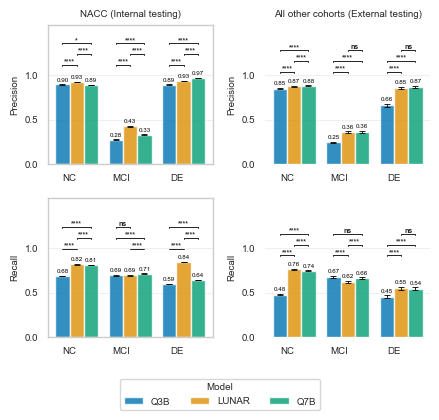

In [35]:
# Create the plot with p-value annotations
plot_classwise_with_pvalues(
    all_metrics=all_metrics,
    pairwise_pvalues=pairwise_comparisons,
    model_map=model_map,
    class_map=class_map,
    output_dir=".",
    show_all_comparisons=True,  # Only show comparisons with baseline (Q3B)
    p_threshold=1,  # Only show significant results
    figname="fig3_cog_stat_id_level",
    metrics=['precision', 'recall'],
    figsize=(4.5, 4)
    # figname="fig3_cog_stat_id_level_f1",
    # metrics=['f1'],
    # figsize=(4, 2.5)
)